## Generative Adversarial Networks (GANs)

Выберите датасет, на котором хотите обучать вашу генеративную модель:
- CelebA: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
- PeopleArt: https://www.kaggle.com/datasets/amanagr/people-art-dataset
- Best Artworks of All Time: https://www.kaggle.com/datasets/ikarus777/best-artworks-of-all-time
- Cartoon Faces (Google's Cartoon Set): https://www.kaggle.com/datasets/brendanartley/cartoon-faces-googles-cartoon-set

Перед началом ознакомьтесь с https://github.com/soumith/ganhacks, советы оттуда можно использовать при выполнении заданий, особенно в задании 4

In [2]:
from pathlib import Path
from typing import Callable, cast

import lightning as L
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torchvision
from lightning.pytorch.loggers import TensorBoardLogger
from PIL import Image
from torch import Tensor, nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

In [4]:
class ImageDataset(Dataset):
    def __init__(
        self,
        datadir: Path,
        transform: Callable[[Image.Image], Tensor],
        pattern: str = "*.jpg",
    ) -> None:
        self.images = list(datadir.rglob(pattern))
        self.transform = transform

    def __getitem__(self, index) -> Tensor:
        img = Image.open(self.images[index])
        return self.transform(img)

    def __len__(self) -> int:
        return len(self.images)

In [5]:
transform = transforms.Compose(
    [
        transforms.Resize(64),
        transforms.CenterCrop(64),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

In [6]:
datadir = Path("/root/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2")
dataset = ImageDataset(
    datadir,
    transform=transform,
)
print(len(dataset))
print(dataset[0].shape)

202599
torch.Size([3, 64, 64])


In [7]:
loader = DataLoader(dataset, batch_size=16, shuffle=True)

batch = next(iter(loader))
print(batch.shape)

torch.Size([16, 3, 64, 64])


In [8]:
class Generator(nn.Module):
    def __init__(self, latent_dim: int = 128):
        super().__init__()
        self.model = nn.Sequential(
            # Input: (batch, latent_dim, 1, 1) -> (512, 4, 4)
            nn.ConvTranspose2d(latent_dim, 512, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            # (512, 4, 4) -> (256, 8, 8)
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # (256, 8, 8) -> (128, 16, 16)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            # (128, 16, 16) -> (64, 32, 32)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # (64, 32, 32) -> (3, 64, 64)
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()  # Output in [-1, 1]
        )

    def forward(self, z: Tensor) -> Tensor:
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Input: (3, 64, 64) -> (64, 32, 32)
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (64, 32, 32) -> (128, 16, 16)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # (128, 16, 16) -> (256, 8, 8)
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # (256, 8, 8) -> (512, 4, 4)
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # (512, 4, 4) -> (1, 1, 1)
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()  # Для vanilla GAN (уберём для LSGAN/WGAN-GP)
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.model(x)

#### Задание 1 (2 балла). Завершите реализацию GAN

Реализуйте методы `generator_step` и `discriminator_step` в классе `GAN` с последней [практики](../notebooks/gan.ipynb)

In [9]:
class GAN(L.LightningModule):
    def __init__(
        self,
        generator: nn.Module,
        discriminator: nn.Module,
        discriminator_period: int = 5,
    ):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.discriminator_period = discriminator_period

        # NB: у нас 2 оптимизатора, поэтому обновлять параметры будем вручную
        self.automatic_optimization = False

    def generate(self, n: int) -> Tensor:
        # Генерируем n изображений из случайного шума
        device = next(self.generator.parameters()).device
        latent_size, *_ = next(self.generator.parameters()).data.shape
        z = torch.randn(n, latent_size, 1, 1, device=device)
        return self.generator(z)

    def training_step(self, batch: Tensor, batch_idx: int) -> None:
        # Шаг генератора
        self.generator_step(batch)

        # Шаг дискриминатора
        if batch_idx % self.discriminator_period == 0:
            self.discriminator_step(batch)

    def configure_optimizers(self):
        # наши 2 оптимизатора: один для параметров генератора, другой — для параметров дискриминатора
        gen_opt = torch.optim.Adam(
            self.generator.parameters(), lr=0.0002, betas=(0.5, 0.999)
        )
        dis_opt = torch.optim.Adam(
            self.discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999)
        )
        return [gen_opt, dis_opt]

    def generator_step(self, batch: Tensor) -> None:
        optimizer_g, _ = self.optimizers(use_pl_optimizer=True)

        # Отключаем расчёт градиентов для параметров, которые не относятся к `optimizer_g`
        self.toggle_optimizer(optimizer_g)
        
        batch_size = batch.size(0)
        device = batch.device

        # Генерируем батч изображений
        latent_size = 128
        z = torch.randn(batch_size, latent_size, 1, 1, device=device)
        fake = self.generator(z)

        # Получаем оценку дискриминатора для `fake`
        fake_scores = self.discriminator(fake)
        # Считаем ошибку генератора
        g_loss = F.binary_cross_entropy_with_logits(fake_scores, torch.ones_like(fake_scores))

        # Обновляем параметры генератора
        self.manual_backward(g_loss)
        optimizer_g.step()
        optimizer_g.zero_grad()

        # Восстанавливаем состояние параметров (обратное действие к `toggle_optimizer`)
        self.untoggle_optimizer(optimizer_g)

        self.log("g_loss", g_loss, prog_bar=True)

    def discriminator_step(self, batch: Tensor) -> None:
        _, optimizer_d = self.optimizers(use_pl_optimizer=True)

        # Отключаем расчёт градиентов для параметров, которые не относятся к `optimizer_d`
        self.toggle_optimizer(optimizer_d)
        
        batch_size = batch.size(0)
        device = batch.device
        latent_size = 128

        # Считаем ошибку дискриминатора на реальных изображениях
        real_scores = self.discriminator(batch)
        real_loss = F.binary_cross_entropy_with_logits(real_scores, torch.ones_like(real_scores))

        # Считаем ошибку дискриминатора на сгенерированных изображениях
        z = torch.randn(batch_size, latent_size, 1, 1, device=device)
        fake = self.generator(z).detach()
        fake_scores = self.discriminator(fake)
        fake_loss = F.binary_cross_entropy_with_logits(fake_scores, torch.zeros_like(fake_scores))

        # Обновляем параметры дискриминатора
        d_loss = 0.5 * (real_loss + fake_loss)
        self.manual_backward(d_loss)
        optimizer_d.step()
        optimizer_d.zero_grad()

        # восстанавливаем состояние параметров (обратное действие к `toggle_optimizer`)
        self.untoggle_optimizer(optimizer_d)

        self.log("d_loss", d_loss, prog_bar=True, on_step=True)
        self.log("real_loss", real_loss, prog_bar=True)
        self.log("fake_loss", fake_loss, prog_bar=True)

    def on_train_epoch_end(self) -> None:
        images = self.generate(16)
        grid = torchvision.utils.make_grid(
            tensor=images,
            nrow=8,
            padding=2,
            normalize=True,
            value_range=(-1, 1),
        )
        str_title = f"{self.__class__.__name__}_images"
        logger = cast(TensorBoardLogger, self.logger)
        logger.experiment.add_image(str_title, grid, global_step=self.global_step)

#### Задание 2 (4 баллов). Базовое обучение

Запустите обучение модели
- минимальное кол-во шагов: 50000 (например 50 эпох по 1000 батчей в каждой)
- минимальный размер батча: 32 (можете увеличить, если не наблюдаете при этом кратной просадки по скорости)
- в конце обучения сгенерируйте 64 изображения

In [10]:
batch_size = 32
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

In [28]:
latent_dim = 128
generator = Generator(latent_dim)
discriminator = Discriminator()
gan = GAN(generator, discriminator, discriminator_period=5)

logger = TensorBoardLogger("logs", name="vanilla_gan")

trainer = L.Trainer(
    max_epochs=8,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    logger=logger,
    log_every_n_steps=100,
    enable_progress_bar=True,
)

trainer.fit(gan, loader)

trainer.save_checkpoint("vanilla_gan.ckpt")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | discriminator | Discriminator | 2.8 M  | train
1 | generator     | Generator     | 3.8 M  | train
--------------------------------------------------------
6.6 M     Trainable params
0         Non-trainable params
6.6 M     Total params
26.287    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=8` reached.


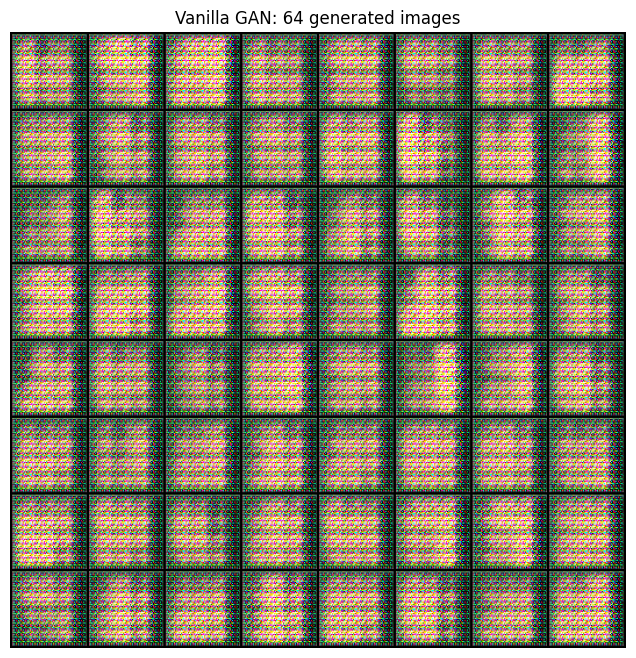

In [30]:
gan.eval()
gan = gan.cuda()
with torch.no_grad():
    images = gan.generate(64)

grid = torchvision.utils.make_grid(
    images,
    nrow=8,
    padding=2,
    normalize=True,
    value_range=(-1, 1),
)

plt.figure(figsize=(8, 8))
plt.imshow(torchvision.transforms.ToPILImage()(grid))
plt.axis('off')
plt.title("Vanilla GAN: 64 generated images")
plt.show()

torchvision.utils.save_image(grid, "vanilla_gan_64.png")

В итоге было 6332 * 8 = 50656 шагов.
Как видно, получился какой-то тильт.

#### Задание 3 (3+5 баллов). Более стабильные версии GAN

Модифицируйте вычисление ошибки для более стабильного обучения. 
- (3 балла) LSGAN (https://paperswithcode.com/method/lsgan)
- (5 балла) Wasserstein GAN + Gradient penalty (https://paperswithcode.com/method/wgan-gp)

Запустите обучение той же длительности, что в задании 2 (>50000 шагов, батч > 32) и сгенерируйте 64 изображения. Сравните результаты с заданием 2

#### Wasserstein GAN + Gradient penalty

In [11]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.model(x).view(-1, 1)

In [12]:
class WGANGP(GAN):
    def __init__(self, generator, discriminator, lambda_gp=10.0, discriminator_period=5):
        super().__init__(generator, discriminator, discriminator_period)
        self.lambda_gp = lambda_gp
        self.automatic_optimization = False

    def configure_optimizers(self):
        opt_g = torch.optim.Adam(self.generator.parameters(), lr=1e-4, betas=(0.0, 0.9))
        opt_d = torch.optim.Adam(self.discriminator.parameters(), lr=1e-4, betas=(0.0, 0.9))
        return opt_g, opt_d

    def generator_step(self, batch):
        opt_g, _ = self.optimizers(use_pl_optimizer=True)
        self.toggle_optimizer(opt_g)

        z = torch.randn(batch.size(0), 128, 1, 1, device=self.device)
        fake = self.generator(z)
        score = self.discriminator(fake)

        g_loss = -score.mean()

        self.manual_backward(g_loss)
        opt_g.step()
        opt_g.zero_grad()
        self.untoggle_optimizer(opt_g)

        self.log("g_loss", g_loss, prog_bar=True)

    def discriminator_step(self, batch):
        opt_g, opt_d = self.optimizers(use_pl_optimizer=True)
        self.toggle_optimizer(opt_d)

        real_imgs = batch
        b_size = real_imgs.size(0)

        d_real = self.discriminator(real_imgs)
        d_real_loss = -d_real.mean()

        z = torch.randn(b_size, 128, 1, 1, device=self.device)
        fake_imgs = self.generator(z).detach()
        d_fake = self.discriminator(fake_imgs)
        d_fake_loss = d_fake.mean()

        alpha = torch.rand(b_size, 1, 1, 1, device=self.device)
        alpha = alpha.expand_as(real_imgs)
        interpolates = (alpha * real_imgs + (1 - alpha) * fake_imgs).requires_grad_(True)
        
        d_interp = self.discriminator(interpolates)
        gradients = torch.autograd.grad(
            outputs=d_interp,
            inputs=interpolates,
            grad_outputs=torch.ones_like(d_interp),
            create_graph=True,
            retain_graph=True,
            only_inputs=True,
        )[0]
        gradients = gradients.view(b_size, -1)
        gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean() * self.lambda_gp

        d_loss = d_real_loss + d_fake_loss + gradient_penalty

        self.manual_backward(d_loss)
        opt_d.step()
        opt_d.zero_grad()
        self.untoggle_optimizer(opt_d)

        self.log_dict({
            "d_loss": d_loss,
            "d_real_loss": d_real_loss,
            "d_fake_loss": d_fake_loss,
            "gp": gradient_penalty,
            "wass_dist": d_real_loss + d_fake_loss,
        }, prog_bar=True)

In [13]:
batch_size = 32
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

generator = Generator(latent_dim=128)
discriminator = Discriminator()

wgangp = WGANGP(
    generator=generator,
    discriminator=discriminator,
    lambda_gp=10.0,
    discriminator_period=5
)

logger = TensorBoardLogger("logs", name="wgan_gp_celeba")

trainer = L.Trainer(
    max_epochs=8,
    accelerator="gpu",
    devices=1,
    logger=logger,
    log_every_n_steps=100,
    enable_progress_bar=True,
)

trainer.fit(wgangp, loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | discriminator | Discriminator | 2.8 M  | train
1 | generator     | Generator     | 3.8 M  | train
---------------------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=8` reached.


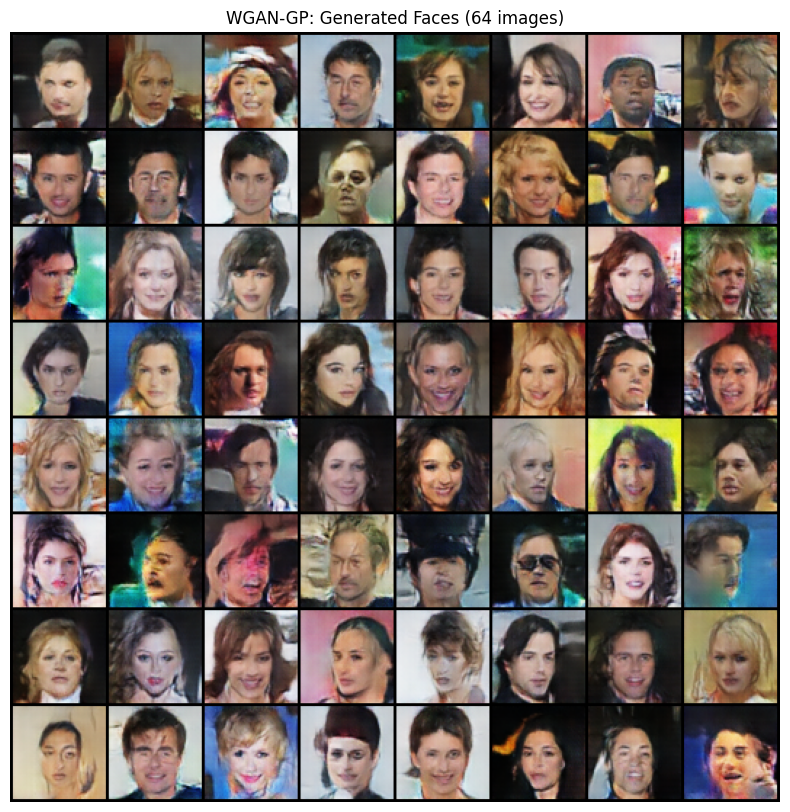

In [14]:
wgangp.eval()
with torch.no_grad():
    fixed_noise = torch.randn(64, 128, 1, 1, device=next(wgangp.parameters()).device)
    generated = wgangp.generator(fixed_noise)

grid = torchvision.utils.make_grid(
    generated, nrow=8, padding=2, normalize=True, value_range=(-1, 1)
)

plt.figure(figsize=(10, 10))
plt.imshow(torchvision.transforms.ToPILImage()(grid))
plt.axis("off")
plt.title("WGAN-GP: Generated Faces (64 images)")
plt.show()

torchvision.utils.save_image(grid, "wgan_gp_final_64.png")

Ну какова красота... все еще 8 эпох, а уже лучше, чем кто-либо, кого я нарисую за всю свою жизнь...

По желанию можно также поменять:
- learning rate оптимизаторов
- относительную частоту обновления весов генератора и дискриминатора
- архитектуры моделей: например, можете увеличить размеры моделей или докинуть слоёв